# Knowledge Discovery in Databases (KDD) Project: Formula 1 Race Outcome
**Obiettivo del Progetto:** Applicare l'intero processo KDD al dataset ufficiale "Formula 1 World Championship (1950-2023)" di Kaggle. L'obiettivo è estrarre conoscenza per prevedere se una vettura concluderà la gara in zona punti (Top 10) conoscendo solo i parametri pre-partenza: posizione in griglia, scuderia e circuito. L'analisi si concentra sull'era turbo-ibrida (dal 2014 ad oggi).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

print("FASE 1: DATA SELECTION")
print("Download del dataset Formula 1 da Kaggle in corso...")

# 1. Download del dataset tramite kagglehub
dataset_path = kagglehub.dataset_download("rohanrao/formula-1-world-championship-1950-2020")
print(f"Download completato. Path: {dataset_path}\n")

# 2. Caricamento delle tabelle relazionali necessarie
try:
    results = pd.read_csv(os.path.join(dataset_path, 'results.csv'))
    races = pd.read_csv(os.path.join(dataset_path, 'races.csv'))
    constructors = pd.read_csv(os.path.join(dataset_path, 'constructors.csv'))
    print("File caricati con successo.")
except Exception as e:
    print(f"Errore nel caricamento dei dati: {e}")

# 3. Join delle tabelle per creare un dataset unico (Data Integration)
# Uniamo i risultati con le informazioni sulla gara (per avere l'anno e il circuito)
df_merged = results.merge(races[['raceId', 'year', 'circuitId', 'name']], on='raceId', how='left')
# Uniamo con le scuderie (per avere il nome del costruttore)
df_merged = df_merged.merge(constructors[['constructorId', 'name']], on='constructorId', how='left', suffixes=('_race', '_constructor'))

# 4. Filtraggio dei dati: selezioniamo solo l'Era Ibrida (dal 2014) per coerenza tecnologica
df_modern = df_merged[df_merged['year'] >= 2014].copy()

print(f"Dimensioni dataset integrato (Era Ibrida): {df_modern.shape}")
df_modern.head()

Matplotlib is building the font cache; this may take a moment.
d:\Progetto_KDD_F1\f1_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FASE 1: DATA SELECTION
Download del dataset Formula 1 da Kaggle in corso...


100%|██████████| 6.28M/6.28M [00:01<00:00, 5.01MB/s]

Extracting files...


Download completato. Path: C:\Users\asua\.cache\kagglehub\datasets\rohanrao\formula-1-world-championship-1950-2020\versions\24

File caricati con successo.
Dimensioni dataset integrato (Era Ibrida): (4626, 22)


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,circuitId,name_race,name_constructor
22127,22130,900,3,131,6,3,1,1,1,25.0,...,5578710,19,1,1:32.478,206.436,1,2014,1,Australian Grand Prix,Mercedes
22128,22131,900,825,1,20,4,2,2,2,18.0,...,5605487,49,6,1:33.066,205.131,1,2014,1,Australian Grand Prix,McLaren
22129,22132,900,18,1,22,10,3,3,3,15.0,...,5608737,39,5,1:32.917,205.460,1,2014,1,Australian Grand Prix,McLaren
22130,22133,900,4,6,14,5,4,4,4,12.0,...,5613994,57,7,1:33.186,204.867,1,2014,1,Australian Grand Prix,Ferrari
22131,22134,900,822,3,77,15,5,5,5,10.0,...,5626349,56,3,1:32.616,206.128,1,2014,1,Australian Grand Prix,Williams


## Fase 2: Data Pre-processing
In questa fase puliamo i dati, gestiamo le anomalie e definiamo la nostra variabile target. Il dataset di F1 di Kaggle utilizza la stringa `\N` per i valori mancanti; dobbiamo gestirla. Inoltre, creeremo la variabile binaria `target_points` (1 se il pilota arriva in Top 10, 0 altrimenti).

FASE 2: DATA PRE-PROCESSING


C:\Users\asua\AppData\Local\Temp\ipykernel_34604\2608055988.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target_points', y='grid', data=df_model, palette='Set2')


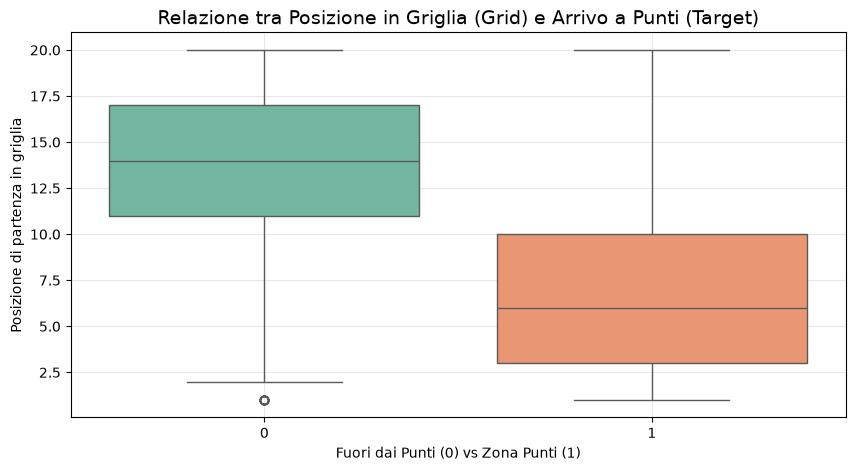

Dataset pronto per la trasformazione. Record validi: 4477


In [2]:
print("FASE 2: DATA PRE-PROCESSING")

# 1. Creazione della variabile target: 'positionOrder' <= 10 significa zona punti
df_modern['target_points'] = (df_modern['positionOrder'] <= 10).astype(int)

# 2. Selezione delle feature pre-gara per evitare Data Leakage 
# (Non possiamo usare 'laps', 'time' o 'status' per prevedere i punti!)
features = ['grid', 'circuitId', 'name_constructor', 'target_points']
df_model = df_modern[features].copy()

# 3. Pulizia e gestione anomalie
# Sostituiamo eventuali "\N" con NaN di pandas
df_model.replace(r'\\N', np.nan, regex=True, inplace=True)

# Rimozione di eventuali righe con valori mancanti (se presenti)
df_model.dropna(inplace=True)

# Escludiamo chi parte dalla pit-lane (grid = 0 nei dati Kaggle) o ha penalità estreme, tenendo solo 1-20
df_model = df_model[(df_model['grid'] > 0) & (df_model['grid'] <= 20)]

# 4. Esplorazione Visiva (Data Exploration)
plt.figure(figsize=(10, 5))
sns.boxplot(x='target_points', y='grid', data=df_model, palette='Set2')
plt.title("Relazione tra Posizione in Griglia (Grid) e Arrivo a Punti (Target)", fontsize=14)
plt.xlabel("Fuori dai Punti (0) vs Zona Punti (1)")
plt.ylabel("Posizione di partenza in griglia")
plt.grid(alpha=0.3)
plt.show()

print(f"Dataset pronto per la trasformazione. Record validi: {len(df_model)}")

## Fase 3: Data Transformation
Prepariamo i dati per l'algoritmo di Machine Learning. 
1. **One-Hot Encoding**: Trasformiamo le variabili categoriche (circuito e scuderia) in variabili dummy (binarie).
2. **Train/Test Split**: Dividiamo il dataset (80% addestramento, 20% test).
3. **Scaling**: Standardizziamo la posizione in griglia per uniformare le distribuzioni.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("FASE 3: DATA TRANSFORMATION")

# 1. One-Hot Encoding per costruttore e circuito
df_transformed = pd.get_dummies(df_model, columns=['name_constructor', 'circuitId'], drop_first=True)

# 2. Divisione Feature (X) e Target (y)
X = df_transformed.drop('target_points', axis=1)
y = df_transformed['target_points']

# 3. Splitting dei dati (con stratificazione sul target)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.copy()
X_test = X_test.copy()

# 4. Standard Scaler per la variabile continua ('grid')
scaler = StandardScaler()
X_train['grid'] = scaler.fit_transform(X_train[['grid']])
X_test['grid'] = scaler.transform(X_test[['grid']])

print(f"Dimensioni Training Set: {X_train.shape}")
print(f"Dimensioni Testing Set: {X_test.shape}")

FASE 3: DATA TRANSFORMATION
Dimensioni Training Set: (3581, 51)
Dimensioni Testing Set: (896, 51)


## Fase 4: Data Mining
Utilizziamo l'algoritmo **Random Forest Classifier** per estrarre pattern di successo. Scegliamo un modello a ensemble perché è molto robusto e gestisce bene dataset con molte variabili codificate in One-Hot (come le scuderie e i circuiti).

In [4]:
from sklearn.ensemble import RandomForestClassifier

print("FASE 4: DATA MINING")

# Inizializzazione del classificatore Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,      # Numero di alberi decisionali
    max_depth=10,          # Profondità massima per limitare l'overfitting
    class_weight='balanced', # Gestione automatica del leggero sbilanciamento delle classi
    random_state=42
)

# Addestramento (Fit) del modello sui dati di train
rf_model.fit(X_train, y_train)

# Generazione delle predizioni sul set di test
y_pred = rf_model.predict(X_test)

print("Addestramento completato. Pattern estratti con successo.")

FASE 4: DATA MINING
Addestramento completato. Pattern estratti con successo.


## Fase 5: Evaluation and Interpretation
Valutiamo la bontà del modello. Analizzeremo la Matrice di Confusione e le metriche principali: **Accuracy, Precision e Recall**. Vogliamo capire quanto il nostro modello sia affidabile nel prevedere chi andrà a punti conoscendo solo la griglia e il team.

FASE 5: EVALUATION AND INTERPRETATION


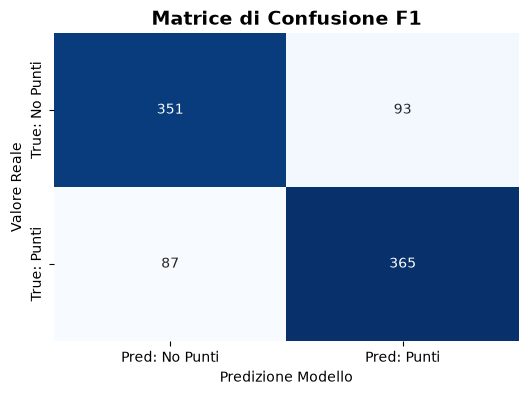


--- METRICHE DI VALUTAZIONE ---
Accuratezza Globale: 79.91%
Precisione (Punti):  79.69%
Recall (Punti):      80.75%
F1-Score:            80.22%


In [5]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print("FASE 5: EVALUATION AND INTERPRETATION")

# 1. Matrice di Confusione
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred: No Punti', 'Pred: Punti'],
            yticklabels=['True: No Punti', 'True: Punti'])
plt.title('Matrice di Confusione F1', fontweight='bold', fontsize=14)
plt.ylabel('Valore Reale')
plt.xlabel('Predizione Modello')
plt.show()

# 2. Metriche matematiche
print("\n--- METRICHE DI VALUTAZIONE ---")
print(f"Accuratezza Globale: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precisione (Punti):  {precision_score(y_test, y_pred)*100:.2f}%")
print(f"Recall (Punti):      {recall_score(y_test, y_pred)*100:.2f}%")
print(f"F1-Score:            {f1_score(y_test, y_pred)*100:.2f}%")

## Fase 6: Use of Discovered Knowledge
Implementiamo un **Decision Support System (DSS)** per ingegneri di pista. Creiamo una funzione in cui inseriamo i parametri del nostro weekend di gara per prevedere in tempo reale se la nostra strategia di qualifica (posizione in griglia) sarà sufficiente per finire a punti con la nostra scuderia.

In [6]:
print("FASE 6: CLINICAL/RACE DECISION SUPPORT SYSTEM (DSS)")

def simula_gara(grid_position, constructor_name, circuit_id):
    """
    Funzione per prevedere il risultato di gara di una vettura.
    """
    # 1. Validazione base degli input
    if not (1 <= grid_position <= 20):
        return "Errore: La posizione in griglia deve essere tra 1 e 20."
    
    # 2. Creazione del DataFrame di input
    input_data = pd.DataFrame([{
        'grid': grid_position,
        'name_constructor': constructor_name,
        'circuitId': circuit_id
    }])
    
    # 3. Trasformazione coerente con il training (One-Hot Encoding)
    input_encoded = pd.get_dummies(input_data)
    # Allineamento delle colonne con quelle che il modello si aspetta, riempiendo di 0 quelle mancanti
    input_aligned = input_encoded.reindex(columns=X.columns, fill_value=0)
    
    # 4. Standardizzazione
    input_aligned['grid'] = scaler.transform(input_aligned[['grid']])
    
    # 5. Predizione probabilistica
    prob = rf_model.predict_proba(input_aligned)[0][1]
    
    print("-" * 50)
    print(f"ANALISI GARA: Scuderia '{constructor_name}' a Circuito ID {circuit_id} partendo P{grid_position}")
    if prob >= 0.5:
        print(f"➡️ RISULTATO ATTESO: ZONA PUNTI (Probabilità: {prob*100:.1f}%)")
    else:
        print(f"➡️ RISULTATO ATTESO: FUORI DAI PUNTI (Probabilità: {prob*100:.1f}%)")
    print("-" * 50)

# Eseguiamo due simulazioni di esempio:
# Scenario 1: Una Ferrari (storicamente top team) che parte 4a
simula_gara(grid_position=4, constructor_name='Ferrari', circuit_id=14)

# Scenario 2: Una Williams (storicamente backmarker nell'era ibrida) che parte 16a nello stesso circuito
simula_gara(grid_position=16, constructor_name='Williams', circuit_id=14)

FASE 6: CLINICAL/RACE DECISION SUPPORT SYSTEM (DSS)
--------------------------------------------------
ANALISI GARA: Scuderia 'Ferrari' a Circuito ID 14 partendo P4
➡️ RISULTATO ATTESO: ZONA PUNTI (Probabilità: 82.2%)
--------------------------------------------------
--------------------------------------------------
ANALISI GARA: Scuderia 'Williams' a Circuito ID 14 partendo P16
➡️ RISULTATO ATTESO: FUORI DAI PUNTI (Probabilità: 19.7%)
--------------------------------------------------
